In [10]:
import os
import matplotlib.patches as patches
import matplotlib.pyplot as plt


def visualize_train_test_split(
    train_ratio=0.7, save_path="beamer/images/train_test_split.png"
):
  """Визуализира пълния комплект от данни отгоре и разделянето на Train/Test отдолу."""
  os.makedirs(os.path.dirname(save_path), exist_ok=True)

  fig, ax = plt.subplots(figsize=(10, 3.5))

  total_width = 10
  height = 1.2  # По-малка височина на правоъгълниците
  spacing = 0.4  # Разстояние между горния и долните блокове

  train_width = total_width * train_ratio
  test_width = total_width * (1 - train_ratio)

  box_style = patches.BoxStyle("Round", pad=0, rounding_size=0.12)

  # 1. Горен правоъгълник — Пълен комплект данни (100%)
  rect_full = patches.FancyBboxPatch(
      (0, height + spacing),
      total_width,
      height,
      boxstyle=box_style,
      facecolor="#7f7f7f",
      edgecolor="black",
      linewidth=2,
      alpha=0.85,
  )
  ax.add_patch(rect_full)

  # 2. Долен правоъгълник — Тренировъчни данни
  rect_train = patches.FancyBboxPatch(
      (0, 0),
      train_width - 0.05,
      height,
      boxstyle=box_style,
      facecolor="#1f77b4",
      edgecolor="black",
      linewidth=2,
      alpha=0.85,
  )
  ax.add_patch(rect_train)

  # 3. Долен правоъгълник — Тестови данни
  rect_test = patches.FancyBboxPatch(
      (train_width + 0.05, 0),
      test_width - 0.05,
      height,
      boxstyle=box_style,
      facecolor="#d62728",
      edgecolor="black",
      linewidth=2,
      alpha=0.85,
  )
  ax.add_patch(rect_test)

  # Текст за пълния комплект
  ax.text(
      total_width / 2,
      height + spacing + height / 2,
      "Пълен комплект от данни (100%)",
      color="white",
      fontsize=13,
      fontweight="bold",
      ha="center",
      va="center",
  )

  # Текст за тренировъчните и тестовите данни
  ax.text(
      (train_width - 0.05) / 2,
      height / 2,
      f"Тренировъчни данни ({train_ratio:.0%})",
      color="white",
      fontsize=12,
      fontweight="bold",
      ha="center",
      va="center",
  )

  ax.text(
      train_width + 0.05 + (test_width - 0.05) / 2,
      height / 2,
      f"Тестови данни ({1 - train_ratio:.0%})",
      color="white",
      fontsize=12,
      fontweight="bold",
      ha="center",
      va="center",
  )

  ax.set_xlim(-0.2, total_width + 0.2)
  ax.set_ylim(-0.2, height * 2 + spacing + 0.2)
  ax.set_aspect("equal")
  ax.axis("off")

  plt.tight_layout()
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
  plt.show()

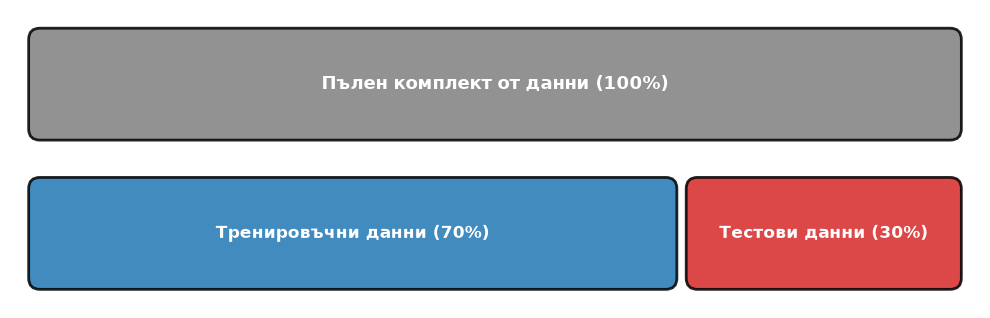

In [11]:
visualize_train_test_split()

Запазено успешно в: beamer/images/5fold_cross_validation.png


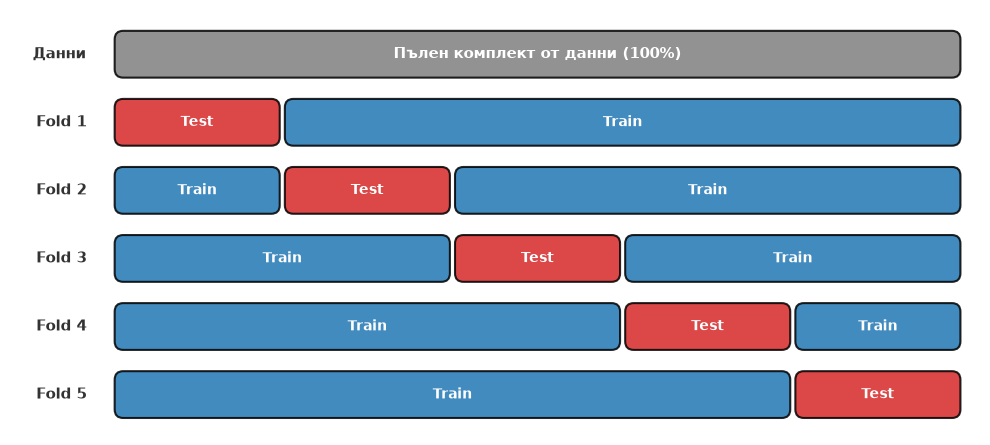

In [14]:
import os
import matplotlib.patches as patches
import matplotlib.pyplot as plt


def visualize_5fold_cv(save_path="beamer/images/5fold_cross_validation.png"):
    """Визуализира 5-Fold Cross Validation със сив блок отгоре (100% данни)

    и съединени тренировъчни блокове с чисти етикети (Train / Test).
    """
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    n_folds = 5
    fig, ax = plt.subplots(figsize=(10, 6))

    total_width = 10
    height = 0.55
    spacing_y = 0.25
    fold_width = total_width / n_folds

    box_style = patches.BoxStyle("Round", pad=0, rounding_size=0.1)

    # 1. Горен сив правоъгълник (Пълен комплект от данни - 100%)
    top_y = n_folds * (height + spacing_y)
    rect_top = patches.FancyBboxPatch(
        (0.03, top_y),
        total_width - 0.06,
        height,
        boxstyle=box_style,
        facecolor="#7f7f7f",
        edgecolor="black",
        linewidth=1.5,
        alpha=0.85,
    )
    ax.add_patch(rect_top)

    ax.text(
        -0.3,
        top_y + height / 2,
        "Данни",
        fontsize=11,
        fontweight="bold",
        ha="right",
        va="center",
        color="#333333",
    )
    ax.text(
        total_width / 2,
        top_y + height / 2,
        "Пълен комплект от данни (100%)",
        color="white",
        fontsize=10.5,
        fontweight="bold",
        ha="center",
        va="center",
    )

    # 2. Чертаене на 5-те итерации (фолдове)
    for i in range(n_folds):
        y_pos = (n_folds - 1 - i) * (height + spacing_y)

        # Етикет за итерацията отляво
        ax.text(
            -0.3,
            y_pos + height / 2,
            f"Fold {i+1}",
            fontsize=11,
            fontweight="bold",
            ha="right",
            va="center",
            color="#333333",
        )

        test_idx = i

        # Блок 1: Преди тестовия блок (ако има)
        if test_idx > 0:
            w_left = test_idx * fold_width
            rect_left = patches.FancyBboxPatch(
                (0.03, y_pos),
                w_left - 0.06,
                height,
                boxstyle=box_style,
                facecolor="#1f77b4",
                edgecolor="black",
                linewidth=1.5,
                alpha=0.85,
            )
            ax.add_patch(rect_left)

        # Блок 2: Тестов блок
        x_test = test_idx * fold_width
        rect_test = patches.FancyBboxPatch(
            (x_test + 0.03, y_pos),
            fold_width - 0.06,
            height,
            boxstyle=box_style,
            facecolor="#d62728",
            edgecolor="black",
            linewidth=1.5,
            alpha=0.85,
        )
        ax.add_patch(rect_test)

        ax.text(
            x_test + fold_width / 2,
            y_pos + height / 2,
            "Test",
            color="white",
            fontsize=10,
            fontweight="bold",
            ha="center",
            va="center",
        )

        # Блок 3: След тестовия блок (ако има)
        if test_idx < n_folds - 1:
            x_right = (test_idx + 1) * fold_width
            w_right = (n_folds - test_idx - 1) * fold_width
            rect_right = patches.FancyBboxPatch(
                (x_right + 0.03, y_pos),
                w_right - 0.06,
                height,
                boxstyle=box_style,
                facecolor="#1f77b4",
                edgecolor="black",
                linewidth=1.5,
                alpha=0.85,
            )
            ax.add_patch(rect_right)

        # Добавяне на текста "Train" върху тренировъчните секции
        if test_idx == 0:
            ax.text(
                fold_width + (total_width - fold_width) / 2,
                y_pos + height / 2,
                "Train",
                color="white",
                fontsize=10,
                fontweight="bold",
                ha="center",
                va="center",
            )
        elif test_idx == n_folds - 1:
            ax.text(
                (total_width - fold_width) / 2,
                y_pos + height / 2,
                "Train",
                color="white",
                fontsize=10,
                fontweight="bold",
                ha="center",
                va="center",
            )
        else:
            ax.text(
                (test_idx * fold_width) / 2,
                y_pos + height / 2,
                "Train",
                color="white",
                fontsize=10,
                fontweight="bold",
                ha="center",
                va="center",
            )
            ax.text(
                (test_idx + 1) * fold_width
                + ((n_folds - test_idx - 1) * fold_width) / 2,
                y_pos + height / 2,
                "Train",
                color="white",
                fontsize=10,
                fontweight="bold",
                ha="center",
                va="center",
            )

    ax.set_xlim(-1.2, total_width + 0.2)
    ax.set_ylim(-0.2, (n_folds + 1) * (height + spacing_y))
    ax.set_aspect("equal")
    ax.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Запазено успешно в: {save_path}")
    plt.show()


visualize_5fold_cv("beamer/images/5fold_cross_validation.png")